In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.cluster.hierarchy import DisjointSet

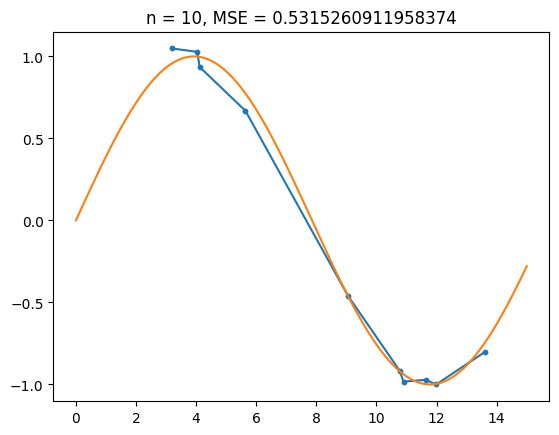

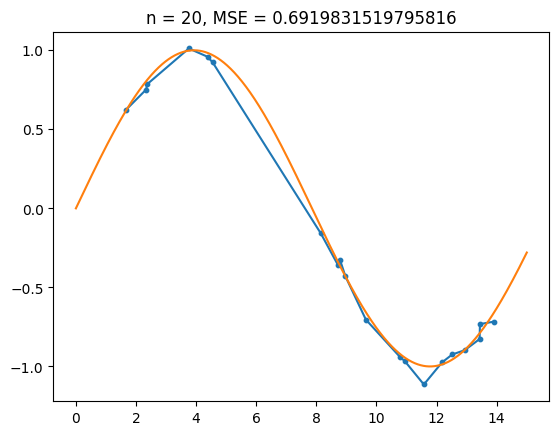

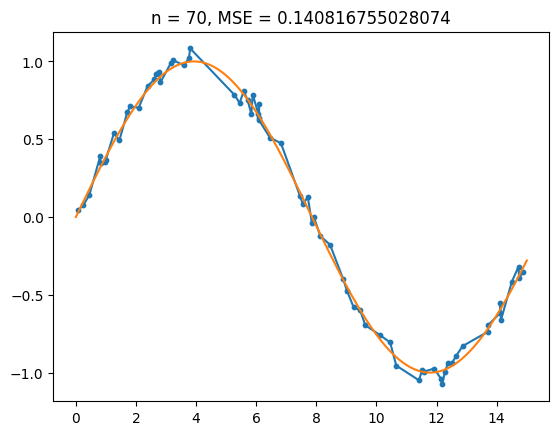

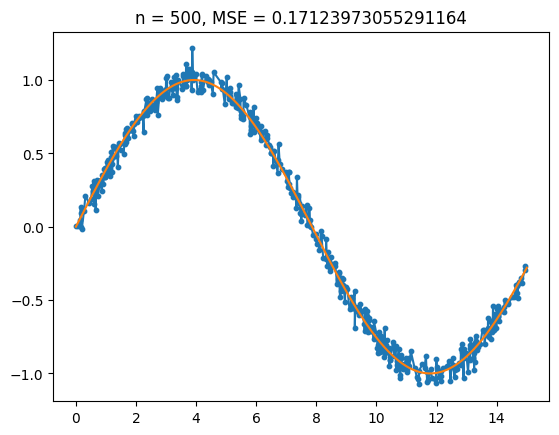

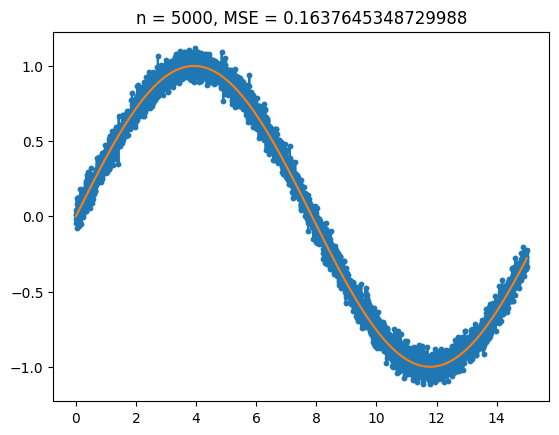

In [138]:
omega = 0.4
n = 20
T = 15

def signal(x):
    return np.sin(omega*x)

#true signal
xt = np.linspace(0,T,1000)
yt = signal(xt)

#sample signal
def sample(signal, num):
    xs = np.sort(15*np.random.rand(num))
    ys = signal(xs)+0.05*np.random.randn(num)

    return xs,ys

def MSE(x,y,signal):
    total = 0
    for i in range(len(x)-1):
        m = (y[i+1]-y[i])/(x[i+1] - x[i])
        b = y[i]-m*x[i]
        curr, curre = quad( lambda t: (signal(t) - (m*t+b))**2, x[i], x[i+1])
        total+= curr
    return (100*total/(x[-1]-x[0]))
        


for num in [10, 20, 70, 500, 5000]:
    xs,ys = sample(signal, num)
    mse = MSE(xs, ys, signal)

    plt.title(f'n = {num}, MSE = {mse}')
    plt.scatter(xs,ys,s=10)
    plt.plot(xs,ys)
    plt.plot(xt,yt)
    plt.show()



In [119]:
def kCluster(xs, k):
    n = len(xs)

    edges = []
    for i in range(n-1):
        edges.append((i,i+1))

    edges.sort(key = lambda edge: xs[edge[1]] - xs[edge[0]])
    
    clusters = DisjointSet(range(n))

    count = n
    i = 0
    while count > k:
            
        p1 = edges[i][0]
        p2 = edges[i][1]
        
        if not clusters.connected(p1,p2):
            clusters.merge(p1,p2)
            count-=1

        i+=1

    return clusters
    

20
18
42
18
1
62
55
9
13
27
60
3
2
165
5


/var/folders/s3/rl7pd8bd54g2b20s8l3xmd180000gn/T/ipykernel_67835/3293558415.py:18: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(xs[j:k], ys[j:k], 1)


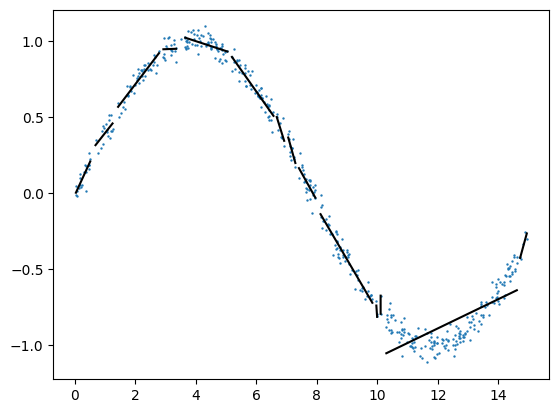

In [133]:
# using the k-clustering algorithm from homework 2

xs, ys = sample(signal, 500)
plt.scatter(xs,ys,s=0.5)
# plt.plot(xs,ys)
# plt.plot(xt,yt)

clusters = kCluster(xs, 15)
start_indices = [0]
for subset in clusters.subsets():
    print(len(subset))
    start_indices.append(start_indices[-1] + len(subset))

for i in range(len(start_indices)-1):
    j = start_indices[i]
    k = start_indices[i+1]

    xs[j:k]
    ys[j:k]
    m, b = np.polyfit(xs[j:k], ys[j:k], 1)
    line = m*xs[j:k] + b
    
    plt.plot(xs[j:k], line, color = 'black')

plt.show()

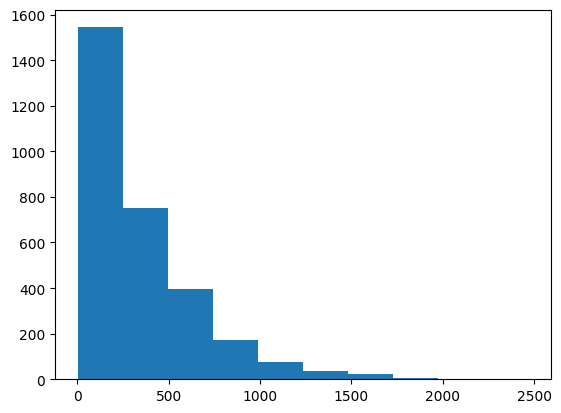

333.3333333333333 98908.20555555559


In [128]:
# this turns out to be DOODOO
# because we get a ton of tiny clusters and a handful of big ones
# see histogram of clustrer sizes below OR the example graph above
n = 5000
k = 15
trials = 200

sizes = []
for i in range(trials):
    xs, ys = sample(signal, n)
    clusters = kCluster(xs, k)
    for subset in clusters.subsets():
        sizes.append(len(subset))

plt.hist(sizes)
plt.show()
print(np.mean(sizes), np.var(sizes))

In [ ]:
class PIECEWISE